=== Geometric Evaluation of H(s) at s2 = -4 + j ===
--------------------------------------------------
• Numerator (Zeros) Parameters:
  r1 = 2.2361,  vartheta_1 = 153.435°
  r2 = 7.0711,  vartheta_2 = 171.870°
• Denominator (Poles) Parameters:
  q1 = 2.8284,  varphi_1 = -135.000°
  q2 = 4.4721,  varphi_2 = 116.565°
  q3 = 1.0000,  varphi_3 = 90.000°
--------------------------------------------------
  => |H(s2)| (Geometric) = 1.250000  (Direct: 1.250000)
  => ∠H(s2) (Geometric) = 253.740° (Direct: -106.260°)
--------------------------------------------------


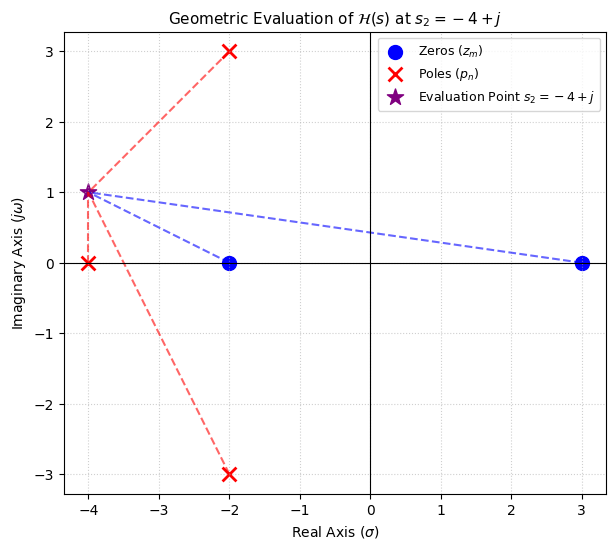

In [8]:
# Notebook: Geometric Evaluation of Transfer Function at s2 = -4 + j (Example)
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import matplotlib.pyplot as plt
import control as ct

# 1. Define Transfer Function and Evaluation Point s2
# H(s) = (s^2 - s - 6) / (s^3 + 8s^2 + 29s + 52)
num_coeffs = [1, -1, -6]
den_coeffs = [1, 8, 29, 52]
H = ct.tf(num_coeffs, den_coeffs)

s_val = -4.0 + 1.0j

# 2. Explicit definition matching the textbook solution notation
# Zeros: z1 = -2, z2 = 3
z1 = -2.0
z2 = 3.0

# Poles: p1 = -2+3j, p2 = -2-3j, p3 = -4
p1 = -2.0 + 3.0j
p2 = -2.0 - 3.0j
p3 = -4.0

K = num_coeffs[0] / den_coeffs[0]

print("=== Geometric Evaluation of H(s) at s2 = -4 + j ===")
print("-" * 50)

# 3. Geometric calculation with direct variable mapping
# Numerator vectors: chi_1 = s2 - z1, chi_2 = s2 - z2
chi_1 = s_val - z1
chi_2 = s_val - z2

r1 = np.abs(chi_1)
vartheta_1 = np.rad2deg(np.angle(chi_1))

r2 = np.abs(chi_2)
vartheta_2 = np.rad2deg(np.angle(chi_2))

# Denominator vectors: xi_1 = s2 - p1, xi_2 = s2 - p2, xi_3 = s2 - p3
xi_1 = s_val - p1
xi_2 = s_val - p2
xi_3 = s_val - p3

q1 = np.abs(xi_1)
varphi_1 = np.rad2deg(np.angle(xi_1))

q2 = np.abs(xi_2)
varphi_2 = np.rad2deg(np.angle(xi_2))

q3 = np.abs(xi_3)
varphi_3 = np.rad2deg(np.angle(xi_3))

# Calculate Magnitude and Phase geometrically
mag_geom = (r1 * r2) / (q1 * q2 * q3) * np.abs(K)
phase_geom = (vartheta_1 + vartheta_2) - (varphi_1 + varphi_2 + varphi_3)

# Direct evaluation for comparison
H_direct = ct.evalfr(H, s_val)
mag_direct = np.abs(H_direct)
phase_direct = np.rad2deg(np.angle(H_direct))

print(f"• Numerator (Zeros) Parameters:")
print(f"  r1 = {r1:.4f},  vartheta_1 = {vartheta_1:.3f}°")
print(f"  r2 = {r2:.4f},  vartheta_2 = {vartheta_2:.3f}°")
print(f"• Denominator (Poles) Parameters:")
print(f"  q1 = {q1:.4f},  varphi_1 = {varphi_1:.3f}°")
print(f"  q2 = {q2:.4f},  varphi_2 = {varphi_2:.3f}°")
print(f"  q3 = {q3:.4f},  varphi_3 = {varphi_3:.3f}°")
print("-" * 50)
print(f"  => |H(s2)| (Geometric) = {mag_geom:.6f}  (Direct: {mag_direct:.6f})")
print(f"  => ∠H(s2) (Geometric) = {phase_geom:.3f}° (Direct: {phase_direct:.3f}°)")
print("-" * 50)

# 4. Visualization of Pole-Zero Map and Vectors to s2 = -4 + j
plt.figure(figsize=(7, 6))

# Plot poles and zeros
plt.scatter([z1, z2], [np.imag(z1), np.imag(z2)], marker='o', color='blue', s=100, label='Zeros ($z_m$)')
plt.scatter([np.real(p1), np.real(p2), p3], [np.imag(p1), np.imag(p2), np.imag(p3)], marker='x', color='red', s=100, linewidths=2, label='Poles ($p_n$)')
plt.scatter([np.real(s_val)], [np.imag(s_val)], marker='*', color='purple', s=150, label='Evaluation Point $s_2 = -4+j$')

# Draw vectors from poles/zeros to s_val
for z in [z1, z2]:
    plt.plot([np.real(z), np.real(s_val)], [np.imag(z), np.imag(s_val)], 'b--', alpha=0.6)
for p in [p1, p2, p3]:
    plt.plot([np.real(p), np.real(s_val)], [np.imag(p), np.imag(s_val)], 'r--', alpha=0.6)

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(r'Geometric Evaluation of $\mathcal{H}(s)$ at $s_2 = -4+j$', fontsize=11)
plt.xlabel(r'Real Axis ($\sigma$)', fontsize=10)
plt.ylabel(r'Imaginary Axis ($j\omega$)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', frameon=True, fontsize=9)
plt.axis('equal')
plt.show()